In [68]:
ruta_resultados = "resultados02"

import pandas as pd
import numpy as np

# --- cargar cuaterniones ---
df_q = pd.read_csv("cuat_estatico.csv")

df_q = df_q.rename(columns={
    "inertial-6286.188861:estOrientQuaternion[0-0]": "q0",
    "inertial-6286.188861:estOrientQuaternion[0-1]": "q1",
    "inertial-6286.188861:estOrientQuaternion[0-2]": "q2",
    "inertial-6286.188861:estOrientQuaternion[0-3]": "q3",
    "inertial-6286.188861:estOrientQuaternion:valid": "qValid",
})

# Comprobar si es un valor válido
# df_q = df_q[df_q["inertial-6286.188861:estOrientQuaternion:valid"] == 1]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# print(df_q)

df_q["time_comp"] = df_q["Time"] * 1e-6
df_q["time_comp"] = df_q["time_comp"].astype(int)
# df_q["time_comp"]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# df_u

df_q

,Time,q0,q1,q2,q3,qValid,time_comp
0,1773412221353142272,0.999612,0.001423,0.000083,-0.027812,1,1773412221353
1,1773412221362933504,0.999612,0.001422,0.000085,-0.027814,1,1773412221362
2,1773412221372630272,0.999612,0.001422,0.000083,-0.027815,1,1773412221372
3,1773412221382233344,0.999612,0.001423,0.000086,-0.027815,1,1773412221382
4,1773412221391745280,0.999612,0.001426,0.000085,-0.027814,1,1773412221391
...,...,...,...,...,...,...,...
22816,1773412454153625088,0.999380,0.001069,0.000019,-0.035201,1,1773412454153
22817,1773412454163692800,0.999380,0.001065,0.000018,-0.035200,1,1773412454163
22818,1773412454173664256,0.999380,0.001062,0.000020,-0.035199,1,1773412454173
22819,1773412454183550976,0.999380,0.001058,0.000017,-0.035202,1,1773412454183


In [69]:
# dt = df_q['dt'].dropna().values
# fs_est = 1 / np.mean(dt)

# print("fs estimada:", fs_est, "Hz")

In [70]:
# cargar aceleraciones
df_a = pd.read_csv("deltas_estatico.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:deltaThetaX": "arx",
    "inertial-6286.188861:deltaThetaY": "ary",
    "inertial-6286.188861:deltaThetaZ": "arz",
    "inertial-6286.188861:deltaVelX": "alx",
    "inertial-6286.188861:deltaVelY": "aly",
    "inertial-6286.188861:deltaVelZ": "alz",
})

# quedarnos solo con datos válidos
# df_a = df_a[
#     (df_a["arXvalid"] == 1) &
#     (df_a["arYvalid"] == 1) &
#     (df_a["arZvalid"] == 1)
# ]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-6
df_a["time_comp"] = df_a["time_comp"].astype(int)
# df_a["time_comp"] 

# df_a["dt"] = df_a["Time"].diff() * 1e-9

df_a

,Time,arx,ary,arz,alx,aly,alz,time_comp
0,1773412221350171136,1.828009e-07,-0.000006,2.908838e-06,-1.414002e-06,-0.000016,-0.009955,1773412221350
1,1773412221359997952,1.007774e-06,0.000005,3.180583e-06,-1.181111e-06,-0.000019,-0.009967,1773412221359
2,1773412221369731584,3.884600e-06,-0.000004,3.396894e-06,4.495935e-06,-0.000016,-0.009954,1773412221369
3,1773412221379370752,-3.971206e-06,-0.000004,2.007291e-06,4.543639e-06,-0.000018,-0.009954,1773412221379
4,1773412221389744896,1.521830e-06,-0.000003,6.248820e-07,-2.621592e-06,-0.000015,-0.009966,1773412221389
...,...,...,...,...,...,...,...,...
22863,1773412454148349696,-2.295067e-06,-0.000009,5.492891e-06,6.276836e-06,-0.000016,-0.009957,1773412454148
22864,1773412454158469120,-7.193992e-06,-0.000002,5.650665e-06,3.034000e-07,-0.000019,-0.009963,1773412454158
22865,1773412454168493056,-5.737263e-06,0.000003,3.629679e-06,2.155671e-06,-0.000015,-0.009950,1773412454168
22866,1773412454178432512,-9.089572e-06,-0.000007,-3.745502e-06,-2.318641e-06,-0.000018,-0.009970,1773412454178


In [71]:
# dt = df_a['dt'].dropna().values
# fs_est = 1 / np.mean(dt)

# print("fs estimada:", fs_est, "Hz")

In [72]:
# import pandas as pd

# # Cargar datos
# data = pd.read_csv("imu_data.csv")

# # Eliminar primera fila (dt = NaN)
# data = data.dropna().reset_index(drop=True)

arx = df_a['arx'].values
ary = df_a['ary'].values
arz = df_a['arz'].values
alx = df_a['alx'].values
aly = df_a['aly'].values
alz = df_a['alz'].values

ang_acc = np.vstack((arx, ary, arz, alx, aly, alz)).T

ang_acc

array([[ 1.82800875e-07, -5.73624675e-06,  2.90883827e-06,
        -1.41400187e-06, -1.63191617e-05, -9.95502435e-03],
       [ 1.00777413e-06,  4.57676651e-06,  3.18058346e-06,
        -1.18111143e-06, -1.94804888e-05, -9.96718369e-03],
       [ 3.88459966e-06, -3.84891428e-06,  3.39689404e-06,
         4.49593472e-06, -1.61440639e-05, -9.95442364e-03],
       ...,
       [-5.73726311e-06,  2.95033078e-06,  3.62967876e-06,
         2.15567070e-06, -1.52181765e-05, -9.95033979e-03],
       [-9.08957190e-06, -7.45255375e-06, -3.74550200e-06,
        -2.31864146e-06, -1.82889744e-05, -9.97005682e-03],
       [-7.20976573e-07,  3.35623531e-06, -3.68367694e-07,
         3.87202999e-06, -1.64007797e-05, -9.95463599e-03]],
      shape=(22868, 6))

In [73]:
import numpy as np
from scipy.signal import butter, sosfilt

fs = 100.0      # Hz
fc = 10.0       # Hz
order = 4

Wn = fc / (fs / 2)

sos = butter(order, Wn, btype='low', output='sos')
print(sos)

accel_filt = sosfilt(sos, ang_acc, axis=0)
accel_filt

[[ 0.00482434  0.00964869  0.00482434  1.         -1.04859958  0.29614036]
 [ 1.          2.          1.          1.         -1.32091343  0.63273879]]


array([[ 8.81894187e-10, -2.76736239e-08,  1.40332346e-08,
        -6.82163054e-09, -7.87292392e-08, -4.80264556e-05],
       [ 1.04790849e-08, -1.54187614e-07,  1.04729097e-07,
        -4.91485515e-08, -5.95447480e-07, -3.53990250e-04],
       [ 6.62690365e-08, -3.97603767e-07,  3.77648313e-07,
        -1.42705157e-07, -2.15492421e-06, -1.25617460e-03],
       ...,
       [ 3.53919608e-06, -2.24626056e-06,  2.91046168e-06,
         2.19824595e-06, -1.77348693e-05, -9.95593062e-03],
       [ 1.87088854e-06, -2.10703742e-06,  3.12102260e-06,
         2.41795982e-06, -1.87677455e-05, -9.95649357e-03],
       [-5.87137068e-07, -2.08539773e-06,  3.29550900e-06,
         2.36331264e-06, -1.92115920e-05, -9.95736198e-03]],
      shape=(22868, 6))

In [74]:
from scipy.signal import butter, filtfilt

def butter_lowpass(fc, fs, order=4):
    wn = fc / (fs / 2)
    b, a = butter(order, wn, btype='low')
    return b, a

fc = 10  # Hz
b, a = butter_lowpass(fc, fs, order=4)

arx_f = filtfilt(b, a, arx)
ary_f = filtfilt(b, a, ary)
arz_f = filtfilt(b, a, arz)
alx_f = filtfilt(b, a, alx)
aly_f = filtfilt(b, a, aly)
alz_f = filtfilt(b, a, alz)
arx_f

array([ 2.46544892e-07,  2.42505264e-07,  1.04193869e-07, ...,
       -3.54867144e-06, -2.49554396e-06, -7.74879810e-07], shape=(22868,))

In [75]:
arx

array([ 1.82800875e-07,  1.00777413e-06,  3.88459966e-06, ...,
       -5.73726311e-06, -9.08957190e-06, -7.20976573e-07], shape=(22868,))

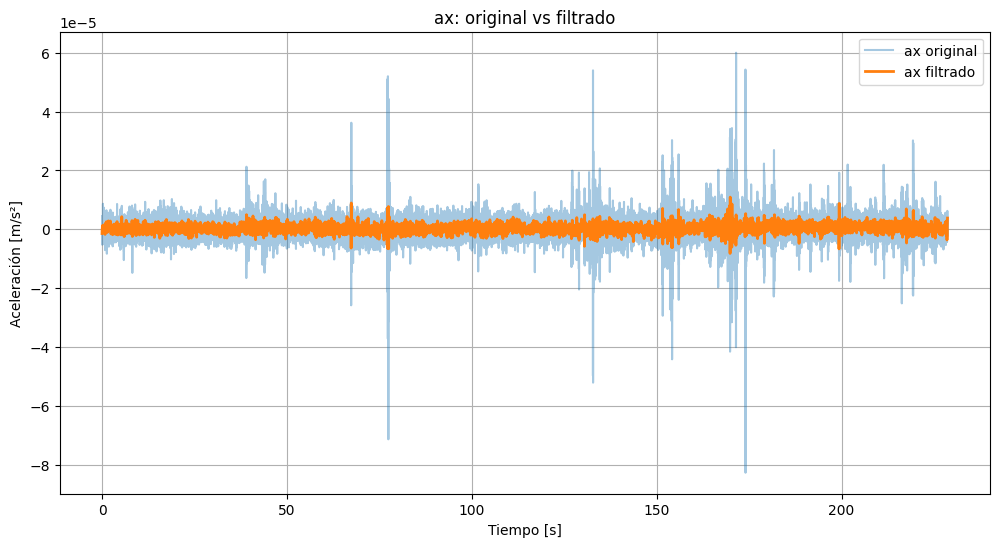

In [76]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(alx)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, alx_f, label='ax filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("ax: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

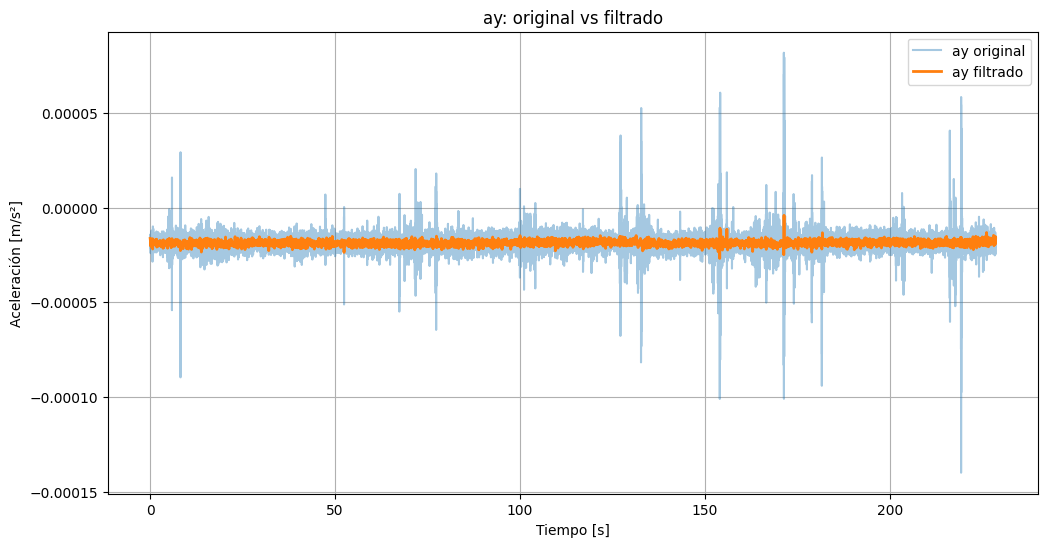

In [77]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(aly)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, aly, label='ay original', alpha=0.4)
plt.plot(t, aly_f, label='ay filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("ay: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

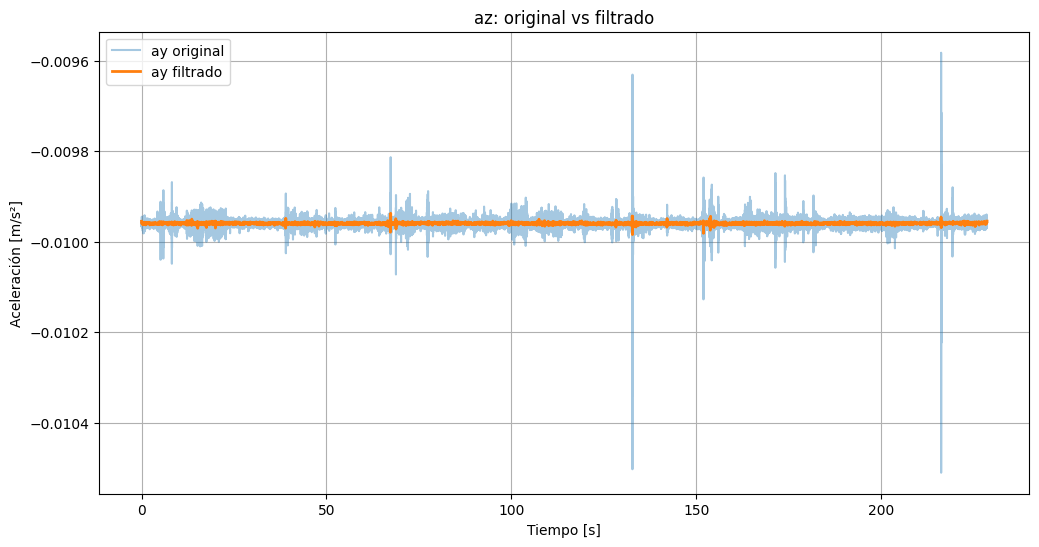

In [78]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(alz)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, alz, label='ay original', alpha=0.4)
plt.plot(t, alz_f, label='ay filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("az: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

In [79]:
print(alx_f.shape)
df_a['arx']

(22868,)


0        1.828009e-07
1        1.007774e-06
2        3.884600e-06
3       -3.971206e-06
4        1.521830e-06
             ...     
22863   -2.295067e-06
22864   -7.193992e-06
22865   -5.737263e-06
22866   -9.089572e-06
22867   -7.209766e-07
Name: arx, Length: 22868, dtype: float64

In [80]:
# print(arx_f.shape)
# df_a['arx']
df_a['arx_f'] = arx_f
df_a['ary_f'] = ary_f
df_a['arz_f'] = arz_f
df_a['alx_f'] = alx_f
df_a['aly_f'] = aly_f
df_a['alz_f'] = alz_f
df_a

,Time,arx,ary,arz,alx,aly,alz,time_comp,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1773412221350171136,1.828009e-07,-0.000006,2.908838e-06,-1.414002e-06,-0.000016,-0.009955,1773412221350,2.465449e-07,-5.719656e-06,2.891187e-06,-1.418714e-06,-0.000016,-0.009955
1,1773412221359997952,1.007774e-06,0.000005,3.180583e-06,-1.181111e-06,-0.000019,-0.009967,1773412221359,2.425053e-07,-4.798369e-06,2.599184e-06,-6.876118e-07,-0.000017,-0.009957
2,1773412221369731584,3.884600e-06,-0.000004,3.396894e-06,4.495935e-06,-0.000016,-0.009954,1773412221369,1.041939e-07,-4.059461e-06,2.341475e-06,-1.556626e-07,-0.000017,-0.009958
3,1773412221379370752,-3.971206e-06,-0.000004,2.007291e-06,4.543639e-06,-0.000018,-0.009954,1773412221379,-2.338407e-07,-3.583030e-06,2.153427e-06,8.183206e-08,-0.000017,-0.009959
4,1773412221389744896,1.521830e-06,-0.000003,6.248820e-07,-2.621592e-06,-0.000015,-0.009966,1773412221389,-7.598346e-07,-3.331009e-06,2.070293e-06,8.285331e-08,-0.000017,-0.009960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22863,1773412454148349696,-2.295067e-06,-0.000009,5.492891e-06,6.276836e-06,-0.000016,-0.009957,1773412454148,-2.361829e-06,-2.802967e-06,3.474851e-06,1.794163e-06,-0.000019,-0.009958
22864,1773412454158469120,-7.193992e-06,-0.000002,5.650665e-06,3.034000e-07,-0.000019,-0.009963,1773412454158,-3.511665e-06,-2.079635e-06,3.020944e-06,1.942263e-06,-0.000019,-0.009958
22865,1773412454168493056,-5.737263e-06,0.000003,3.629679e-06,2.155671e-06,-0.000015,-0.009950,1773412454168,-3.548671e-06,-7.460217e-07,2.175724e-06,2.342568e-06,-0.000018,-0.009958
22866,1773412454178432512,-9.089572e-06,-0.000007,-3.745502e-06,-2.318641e-06,-0.000018,-0.009970,1773412454178,-2.495544e-06,1.147805e-06,9.993254e-07,3.005741e-06,-0.000017,-0.009956


In [81]:
df_q

,Time,q0,q1,q2,q3,qValid,time_comp
0,1773412221353142272,0.999612,0.001423,0.000083,-0.027812,1,1773412221353
1,1773412221362933504,0.999612,0.001422,0.000085,-0.027814,1,1773412221362
2,1773412221372630272,0.999612,0.001422,0.000083,-0.027815,1,1773412221372
3,1773412221382233344,0.999612,0.001423,0.000086,-0.027815,1,1773412221382
4,1773412221391745280,0.999612,0.001426,0.000085,-0.027814,1,1773412221391
...,...,...,...,...,...,...,...
22816,1773412454153625088,0.999380,0.001069,0.000019,-0.035201,1,1773412454153
22817,1773412454163692800,0.999380,0.001065,0.000018,-0.035200,1,1773412454163
22818,1773412454173664256,0.999380,0.001062,0.000020,-0.035199,1,1773412454173
22819,1773412454183550976,0.999380,0.001058,0.000017,-0.035202,1,1773412454183


In [82]:
df_a

,Time,arx,ary,arz,alx,aly,alz,time_comp,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1773412221350171136,1.828009e-07,-0.000006,2.908838e-06,-1.414002e-06,-0.000016,-0.009955,1773412221350,2.465449e-07,-5.719656e-06,2.891187e-06,-1.418714e-06,-0.000016,-0.009955
1,1773412221359997952,1.007774e-06,0.000005,3.180583e-06,-1.181111e-06,-0.000019,-0.009967,1773412221359,2.425053e-07,-4.798369e-06,2.599184e-06,-6.876118e-07,-0.000017,-0.009957
2,1773412221369731584,3.884600e-06,-0.000004,3.396894e-06,4.495935e-06,-0.000016,-0.009954,1773412221369,1.041939e-07,-4.059461e-06,2.341475e-06,-1.556626e-07,-0.000017,-0.009958
3,1773412221379370752,-3.971206e-06,-0.000004,2.007291e-06,4.543639e-06,-0.000018,-0.009954,1773412221379,-2.338407e-07,-3.583030e-06,2.153427e-06,8.183206e-08,-0.000017,-0.009959
4,1773412221389744896,1.521830e-06,-0.000003,6.248820e-07,-2.621592e-06,-0.000015,-0.009966,1773412221389,-7.598346e-07,-3.331009e-06,2.070293e-06,8.285331e-08,-0.000017,-0.009960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22863,1773412454148349696,-2.295067e-06,-0.000009,5.492891e-06,6.276836e-06,-0.000016,-0.009957,1773412454148,-2.361829e-06,-2.802967e-06,3.474851e-06,1.794163e-06,-0.000019,-0.009958
22864,1773412454158469120,-7.193992e-06,-0.000002,5.650665e-06,3.034000e-07,-0.000019,-0.009963,1773412454158,-3.511665e-06,-2.079635e-06,3.020944e-06,1.942263e-06,-0.000019,-0.009958
22865,1773412454168493056,-5.737263e-06,0.000003,3.629679e-06,2.155671e-06,-0.000015,-0.009950,1773412454168,-3.548671e-06,-7.460217e-07,2.175724e-06,2.342568e-06,-0.000018,-0.009958
22866,1773412454178432512,-9.089572e-06,-0.000007,-3.745502e-06,-2.318641e-06,-0.000018,-0.009970,1773412454178,-2.495544e-06,1.147805e-06,9.993254e-07,3.005741e-06,-0.000017,-0.009956


In [83]:
df_u = pd.merge(
    df_q,
    df_a,
    on="time_comp",
    how="inner"
)
df_u

,Time_x,q0,q1,q2,q3,qValid,time_comp,Time_y,arx,ary,arz,alx,aly,alz,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1773412221479719936,0.999612,0.001417,0.000076,-0.027819,1,1773412221479,1773412221479746816,0.000005,-2.331112e-06,6.705229e-06,-3.624289e-06,-0.000024,-0.009965,1.859960e-06,-0.000003,0.000004,6.666208e-07,-0.000020,-0.009960
1,1773412221489293312,0.999612,0.001418,0.000076,-0.027817,1,1773412221489,1773412221489983232,-0.000001,-1.348002e-06,1.541400e-06,1.183070e-07,-0.000017,-0.009954,2.270907e-06,-0.000003,0.000004,6.020294e-07,-0.000020,-0.009961
2,1773412221529278720,0.999612,0.001426,0.000072,-0.027816,1,1773412221529,1773412221529947648,-0.000002,-4.697526e-06,7.127436e-06,2.195341e-06,-0.000020,-0.009953,-6.346529e-07,-0.000003,0.000006,1.219864e-06,-0.000019,-0.009961
3,1773412221539031552,0.999612,0.001425,0.000071,-0.027815,1,1773412221539,1773412221539699456,-0.000006,-2.091238e-06,7.966265e-06,9.474139e-07,-0.000021,-0.009951,-1.309947e-06,-0.000003,0.000006,1.302359e-06,-0.000019,-0.009960
4,1773412222100503296,0.999612,0.001394,0.000070,-0.027812,1,1773412222100,1773412222100147456,-0.000005,-3.908552e-07,6.385339e-06,-1.297494e-06,-0.000010,-0.009966,-6.067861e-07,-0.000004,0.000007,1.226968e-06,-0.000017,-0.009959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2251,1773412453578099200,0.999381,0.001029,0.000062,-0.035175,1,1773412453578,1773412453578093312,0.000001,3.357300e-06,4.131409e-06,1.708859e-06,-0.000012,-0.009953,1.499421e-07,-0.000003,0.000002,2.331326e-06,-0.000016,-0.009960
2252,1773412453587947008,0.999381,0.001031,0.000064,-0.035175,1,1773412453587,1773412453587898368,-0.000004,-2.247797e-06,-2.174722e-06,3.589433e-06,-0.000015,-0.009966,-1.242877e-06,-0.000004,0.000002,2.238177e-06,-0.000016,-0.009960
2253,1773412453597654016,0.999381,0.001029,0.000064,-0.035177,1,1773412453597,1773412453597609472,-0.000003,-5.557854e-06,-2.826827e-07,5.644072e-06,-0.000019,-0.009948,-2.668135e-06,-0.000004,0.000002,1.642550e-06,-0.000015,-0.009960
2254,1773412453607267072,0.999381,0.001029,0.000062,-0.035179,1,1773412453607,1773412453607400192,-0.000001,-4.722062e-06,2.523510e-06,1.934160e-07,-0.000012,-0.009970,-3.843937e-06,-0.000004,0.000002,6.910072e-07,-0.000015,-0.009960


In [84]:
df_u = df_u.rename(columns={"Time_x": "time"})
df_u.drop(["Time_y"], axis=1, inplace=True)
# df_u

df_u["dt"] = df_u["time"].diff() * 1e-9
# df_u

new_order = ['time', 'q0', 'q1', 'q2', 'q3', 'arx', 'ary', 'arz', 'alx', 'aly', 'alz','dt', 'arx_f', 'ary_f', 'arz_f', 'alx_f', 'aly_f', 'alz_f']
df_u = df_u[new_order]
# print(df_u)
df_u

,time,q0,q1,q2,q3,arx,ary,arz,alx,aly,alz,dt,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1773412221479719936,0.999612,0.001417,0.000076,-0.027819,0.000005,-2.331112e-06,6.705229e-06,-3.624289e-06,-0.000024,-0.009965,NaN,1.859960e-06,-0.000003,0.000004,6.666208e-07,-0.000020,-0.009960
1,1773412221489293312,0.999612,0.001418,0.000076,-0.027817,-0.000001,-1.348002e-06,1.541400e-06,1.183070e-07,-0.000017,-0.009954,0.009573,2.270907e-06,-0.000003,0.000004,6.020294e-07,-0.000020,-0.009961
2,1773412221529278720,0.999612,0.001426,0.000072,-0.027816,-0.000002,-4.697526e-06,7.127436e-06,2.195341e-06,-0.000020,-0.009953,0.039985,-6.346529e-07,-0.000003,0.000006,1.219864e-06,-0.000019,-0.009961
3,1773412221539031552,0.999612,0.001425,0.000071,-0.027815,-0.000006,-2.091238e-06,7.966265e-06,9.474139e-07,-0.000021,-0.009951,0.009753,-1.309947e-06,-0.000003,0.000006,1.302359e-06,-0.000019,-0.009960
4,1773412222100503296,0.999612,0.001394,0.000070,-0.027812,-0.000005,-3.908552e-07,6.385339e-06,-1.297494e-06,-0.000010,-0.009966,0.561472,-6.067861e-07,-0.000004,0.000007,1.226968e-06,-0.000017,-0.009959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2251,1773412453578099200,0.999381,0.001029,0.000062,-0.035175,0.000001,3.357300e-06,4.131409e-06,1.708859e-06,-0.000012,-0.009953,0.009896,1.499421e-07,-0.000003,0.000002,2.331326e-06,-0.000016,-0.009960
2252,1773412453587947008,0.999381,0.001031,0.000064,-0.035175,-0.000004,-2.247797e-06,-2.174722e-06,3.589433e-06,-0.000015,-0.009966,0.009848,-1.242877e-06,-0.000004,0.000002,2.238177e-06,-0.000016,-0.009960
2253,1773412453597654016,0.999381,0.001029,0.000064,-0.035177,-0.000003,-5.557854e-06,-2.826827e-07,5.644072e-06,-0.000019,-0.009948,0.009707,-2.668135e-06,-0.000004,0.000002,1.642550e-06,-0.000015,-0.009960
2254,1773412453607267072,0.999381,0.001029,0.000062,-0.035179,-0.000001,-4.722062e-06,2.523510e-06,1.934160e-07,-0.000012,-0.009970,0.009613,-3.843937e-06,-0.000004,0.000002,6.910072e-07,-0.000015,-0.009960


In [85]:
# solo como comprobación

import numpy as np

dt = df_u['dt'].dropna().values
fs_est = 1 / np.mean(dt)

print("fs estimada:", fs_est, "Hz")

fs estimada: 9.713655671413624 Hz


In [86]:
# import numpy as np

# # Inicializar columnas
# for col in ["vx", "vy", "vz", "px", "py", "pz"]:
#     df_u[col] = 0.0

# p = np.zeros(3)
# v = np.ones(3)

# # Umbrales
# ACC_TH = 0.1       # m/s^2
# GYRO_TH = np.deg2rad(1.0)  # rad/s

# print(v.shape)
# print(df_u.loc[k, ["vx", "vy", "vz"]].shape)
# # len(df_a)

# a = df_u.loc[2, ["alx", "aly", "alz"]].values
# a.shape

# v.shape
# dt = 0.01
# # np.zeros(3).shape

# a = df_u.loc[2, ["alx", "aly", "alz"]].values.copy()
# print(type(a), a.shape)
# a[1] = 0.0
# print(a[1], a.flags)

# arr_1d = np.array([1, 2, 3, 4, 5])
# print(arr_1d.shape)
# arr_1d[2] = 99  # Modifies the third element (index 2)
# print(arr_1d)


# print(v, v.shape)
# v[1] = 0
# print(v, v.shape)

# x = v + a#*dt
# x

In [87]:
# a = df_a.loc[3, ["alx", "aly", "alz"]].values
# a

In [88]:
# def zupt_acc_ang(a, g, v):
#     if np.linalg.norm(a) < ACC_TH and np.linalg.norm(g) < GYRO_TH:
#         v = np.zeros(3)   # ZUPT duro

In [89]:
# ACC_TH_ENERGY = (0.02**2)*3 # = 0.0012

Threshold alx_f: 4.227038677343227e-06
Threshold aly_f: -1.5078857712752212e-05
Threshold alz_f: -0.009954289532671414
Threshold norm(alx_f,aly_f): 2.2457722189803895e-05
Threshold norm(alx_f,alz_f): 0.00996529193273979
Threshold norm(aly_f,alz_f): 0.009965309874767727
Threshold norm(alx_f,aly_f,alz_f): 0.009961642317126599


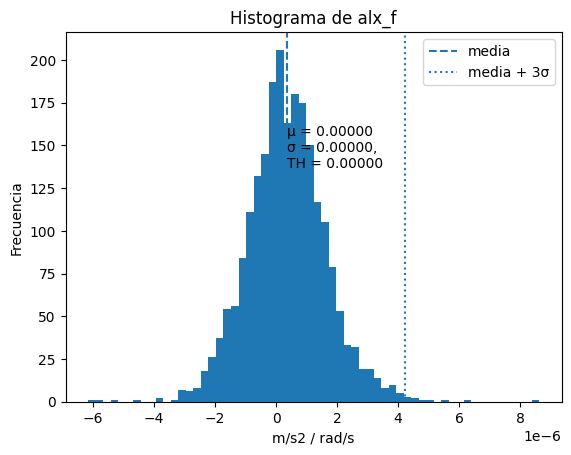

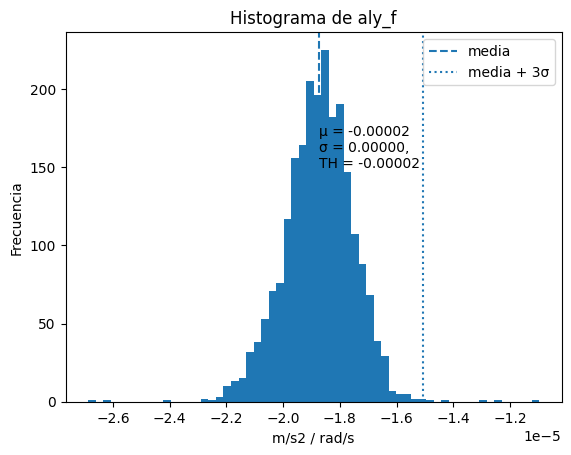

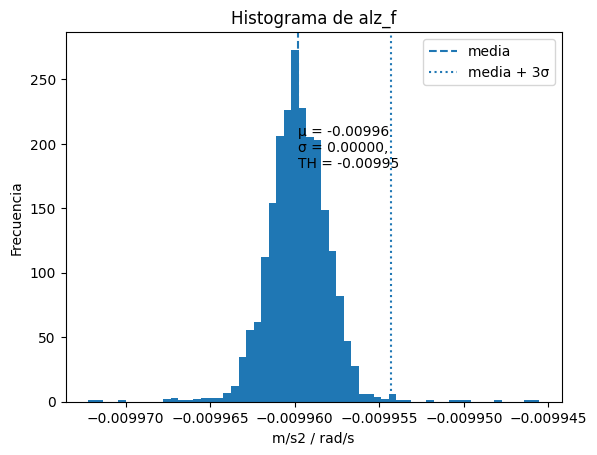

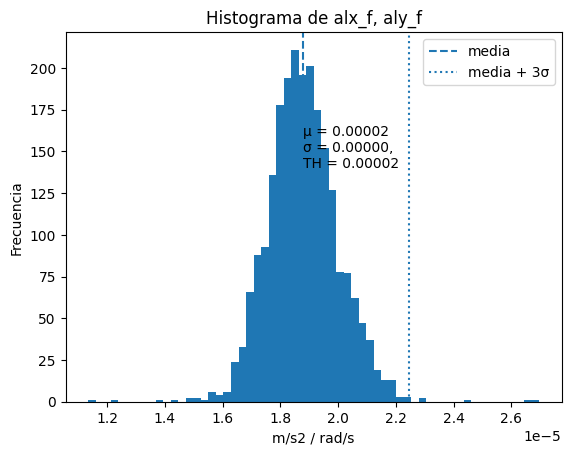

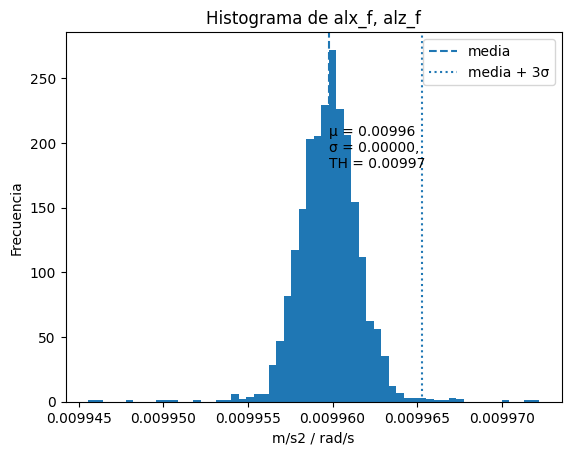

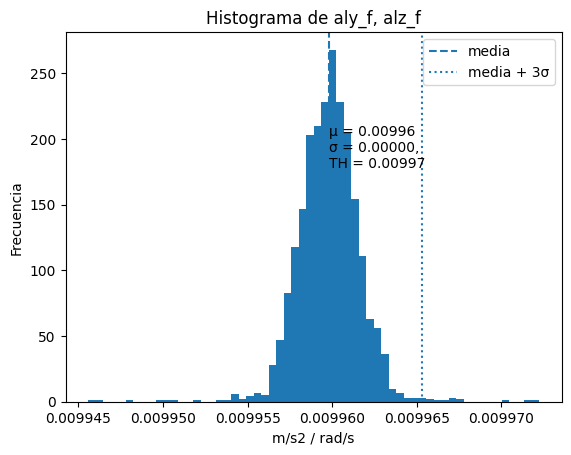

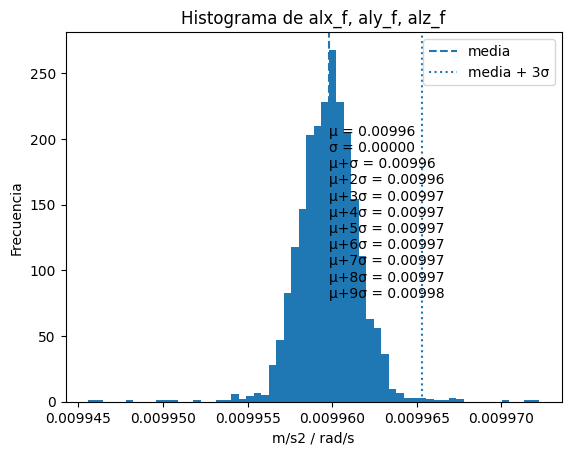

In [90]:
# σ describe ruido + vibración

# segun prueba obtener umbrales y ganancias
import numpy as np
import matplotlib.pyplot as plt

# accl = df_u[["alx_f", "aly_f", "alz_f"]].values#.copy()
# print(accl)
# gyro = df_u[["arx_f", "ary_f", "arz_f"]].values

def histogramaUnEje(axis):
    axis_values = df_u[axis].values
    # axis_values = np.linalg.norm(axis_values)

    axis_mean  = np.mean(axis_values)
    axis_std   = np.std(axis_values)
    th_value = axis_mean + 3*axis_std

    plt.figure()
    plt.hist(axis_values, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f},\nTH = {th_value:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis}")
    plt.legend()

    print(f"Threshold {axis}: {th_value}")

def histogramaDosEjes(axis1, axis2):
    axis_values = df_u[[axis1, axis2]].values
    axis_norm  = np.linalg.norm(axis_values, axis=1)

    axis_mean  = np.mean(axis_norm)
    axis_std   = np.std(axis_norm)
    th_value = axis_mean + 3*axis_std

    plt.figure()
    plt.hist(axis_norm, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f},\nTH = {th_value:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis1}, {axis2}")
    plt.legend()

    print(f"Threshold norm({axis1},{axis2}): {th_value}")

def histogramaTresEjes(axis1, axis2, axis3):
    axis_values = df_u[[axis1, axis2, axis3]].values
    axis_norm  = np.linalg.norm(axis_values, axis=1)

    axis_mean  = np.mean(axis_norm)
    axis_std   = np.std(axis_norm)
    th_value = axis_mean + 1*axis_std
    th2_value = axis_mean + 2*axis_std
    th3_value = axis_mean + 3*axis_std
    th4_value = axis_mean + 4*axis_std
    th5_value = axis_mean + 5*axis_std
    th6_value = axis_mean + 6*axis_std
    th7_value = axis_mean + 7*axis_std
    th8_value = axis_mean + 8*axis_std
    th9_value = axis_mean + 9*axis_std

    plt.figure()
    plt.hist(axis_norm, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f}\nμ+σ = {th_value:.5f}\nμ+2σ = {th2_value:.5f}\nμ+3σ = {th3_value:.5f}\nμ+4σ = {th4_value:.5f}\nμ+5σ = {th5_value:.5f}\nμ+6σ = {th6_value:.5f}\nμ+7σ = {th7_value:.5f}\nμ+8σ = {th8_value:.5f}\nμ+9σ = {th9_value:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis1}, {axis2}, {axis3}")
    plt.legend()
    
    print(f"Threshold norm({axis1},{axis2},{axis3}): {th_value}")

histogramaUnEje("alx_f")
histogramaUnEje("aly_f")
histogramaUnEje("alz_f")
histogramaDosEjes("alx_f", "aly_f")
histogramaDosEjes("alx_f", "alz_f")
histogramaDosEjes("aly_f", "alz_f")
histogramaTresEjes("alx_f", "aly_f", "alz_f")

Threshold arx_f: 5.621137540580648e-06
Threshold ary_f: 3.946845974888062e-06
Threshold arz_f: 6.402627693052504e-06
Threshold norm(arx_f,ary_f): 7.041540045874166e-06
Threshold norm(arx_f,arz_f): 7.124464024173283e-06
Threshold norm(ary_f,arz_f): 7.331512618822888e-06
Threshold norm(arx_f,ary_f,arz_f): 5.377768766076942e-06


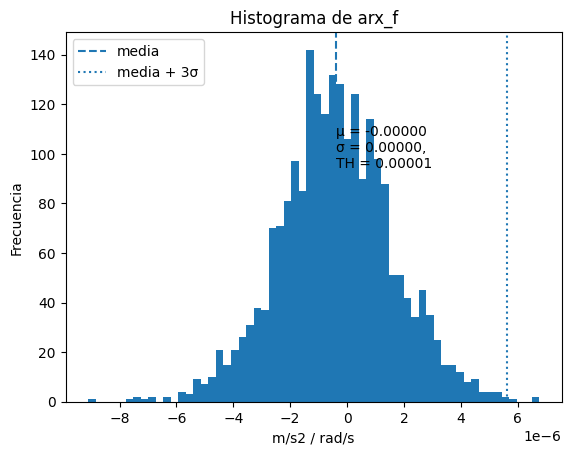

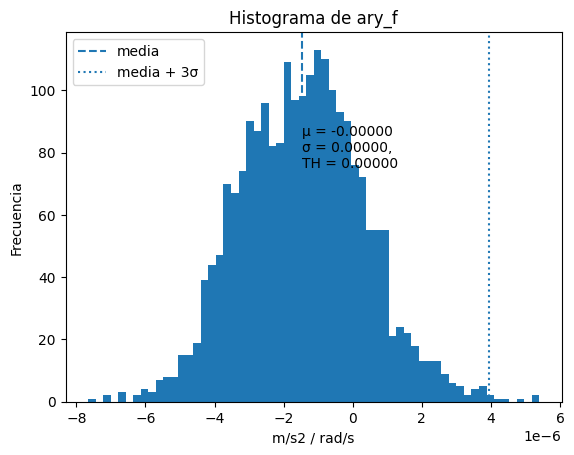

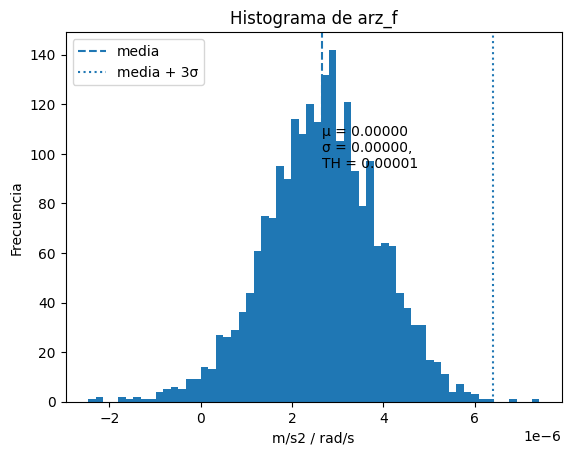

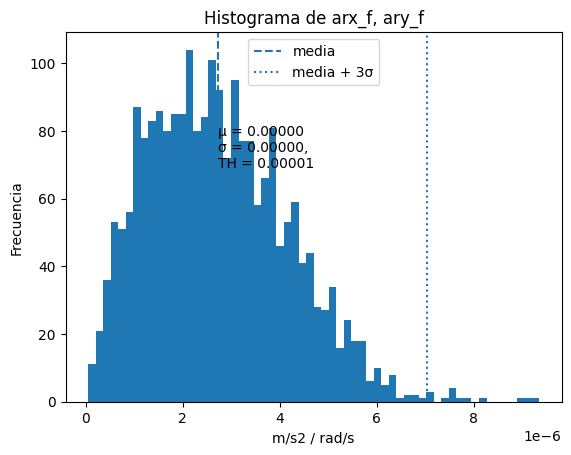

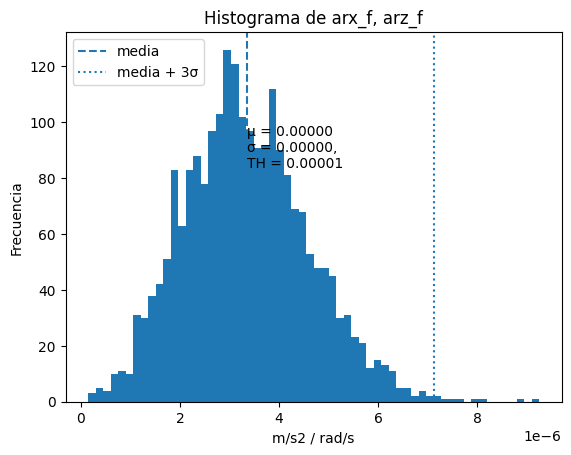

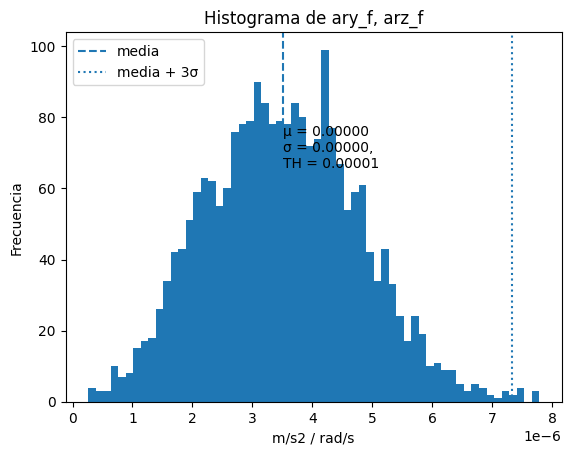

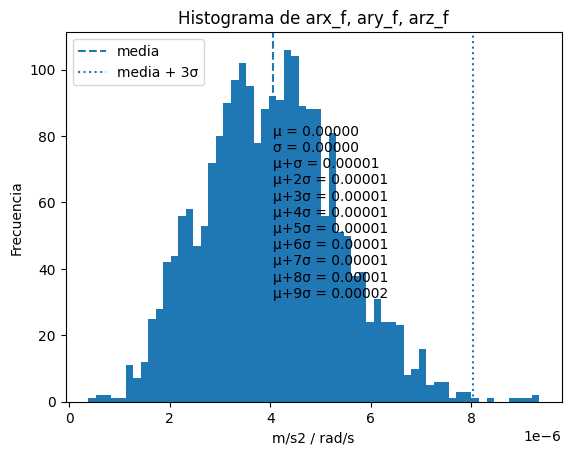

In [91]:
histogramaUnEje("arx_f")
histogramaUnEje("ary_f")
histogramaUnEje("arz_f")
histogramaDosEjes("arx_f", "ary_f")
histogramaDosEjes("arx_f", "arz_f")
histogramaDosEjes("ary_f", "arz_f")
histogramaTresEjes("arx_f", "ary_f", "arz_f")

In [92]:
"""ACC_TH   = 0.15          # m/s²
GYRO_TH  = np.deg2rad(1)

K_zupt   = 0.5
K_nhc_y  = 0.8
K_nhc_z  = 0.9

G_acc    = 0.8
G_gyro   = 1.0"""

'ACC_TH   = 0.15          # m/s²\nGYRO_TH  = np.deg2rad(1)\n\nK_zupt   = 0.5\nK_nhc_y  = 0.8\nK_nhc_z  = 0.9\n\nG_acc    = 0.8\nG_gyro   = 1.0'

In [93]:
# x1 = 2.5
# x0 = 0.5
# x = 1 / (1+((np.e)**-(1*(x-x))))
# x

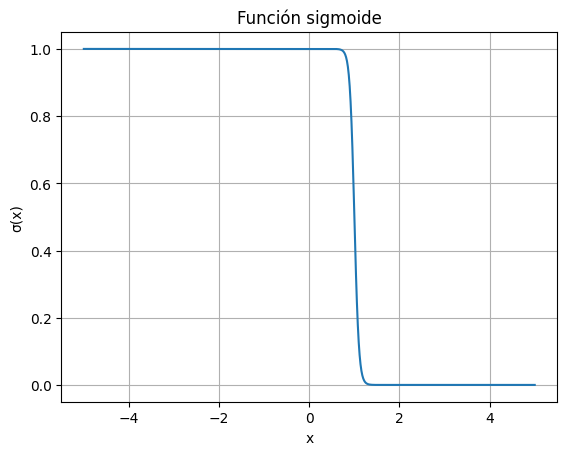

In [94]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid_k(x, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=20.0):
    # k = 10 # que tan rápido crece la transición, espacio entre rangos
    # x0 = 0.5 # punto de activación - umbral # control de reposo
    valor_min = 0
    valor_max = 1
    # s = 1 / (1 + np.exp(-k*(x-x0)))
    # z = 1 / (1 + np.exp(k * (x - x0)))
    # z = np.clip(z, 0, 60)  # evita overflow

    z = ZUPT_SIGMOID_GAIN * (x - ZUPT_X0)
    z = np.clip(z, -10, 10)  # evita overflow
    z = 1 / (1 + np.exp(z))
    return valor_min + (valor_max - valor_min) * z

x = np.linspace(-5, 5, 1000)
y = sigmoid_k(x)

plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.title("Función sigmoide")
plt.grid(True)
plt.show()

# Criterio de eleccion de ruido
# ACC_TH  ≈ 3σ_acc
# GYRO_TH ≈ 3σ_gyro

In [95]:
pruebinia = sigmoid_k(0.527151, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=10.0)
pruebinia

np.float64(0.9912376484362222)

In [96]:
y = 1 / (1+((np.e)**-2.5))
y

0.9241418199787566

In [97]:
# G_acc ≈ 1.0 en recta

# G_acc ≈ 0.7 si vibra mucho

# G_acc ≈ 0.3 si hay mucho ruido

In [98]:
# from scipy.spatial.transform import Rotation as R

# def sigmoid_k(x, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=20.0):
#     valor_min = 0
#     valor_max = 1
#     z = ZUPT_SIGMOID_GAIN * (x - ZUPT_X0)
#     z = np.clip(z, -10, 10)
#     z = 1 / (1 + np.exp(z))
#     return valor_min + (valor_max - valor_min) * z

#     """ 
#     G_acc = 0.8   # 1 = full confianza
#     G_gyro = 1.0

#     # Umbrales de ZUPT
#     ACC_TH = 0.269
#     GYRO_TH = 0.0172

#     K_zupt = 0.5

#     # # restricciones vehículo
#     K_nhc_y = 0.2   # lateral
#     K_nhc_z = 0.1   # vertical
#     """

# def ins(df=df_u,
#         G_acc=1.0,
#         G_gyro=1.0,
#         p_gain=1.0,
#         ACC_TH=0.0732, # ACC_TH=0.269,
#         GYRO_TH=0.0112, # GYRO_TH=0.0172,
#         ZUPT_GAIN=0.5,
#         ZUPT_X0=1.0,
#         ZUPT_SIGMOID_GAIN=1.0,
#         K_nhc_y=0.9,
#         K_nhc_z=0.9,
#         dt = 0.01):

#     p = np.zeros(3)
#     p_scale = np.zeros(3)
#     v = np.zeros(3)
#     v_body = np.zeros(3)

#     for k in range(0, len(df)):

#         if pd.isna(dt):
#             continue

#         a_body = df.loc[k, ["alx_f", "aly_f", "alz_f"]].values.copy()
#         g = df.loc[k, ["arx_f", "ary_f", "arz_f"]].values

#         gyro_gain = np.linalg.norm(G_gyro * g)

#         q = df.loc[k, ["q0", "q1", "q2", "q3"]].values
#         # 1) Normalizar cuaternión
#         q = q / np.linalg.norm(q)

#         # 2) Rotación body → inercial
#         r = R.from_quat([q[1], q[2], q[3], q[0]])
#         R_nb = r.as_matrix().T   # body → nav

#         # 3) Aceleración en marco inercial
#         a_nav = G_acc * (R_nb @ a_body)

#         df.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = a_nav

#         # Velocidad
#         v = v + a_nav * dt

#         v = v + R_nb @ delta_v + g_nav * dt # g_nav ¿

#         df.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

#         acc_norm  = np.linalg.norm(a_body)
#         gyro_norm = np.linalg.norm(gyro_gain)

#         s_acc  = acc_norm  / ACC_TH
#         s_gyro = gyro_norm / GYRO_TH

#         zupt_score = max(s_acc, s_gyro)

#         df.loc[k, ["acc_norm", "gyro_norm", "s_acc", "s_gyro", "zupt_score"]] = acc_norm, gyro_norm, s_acc, s_gyro, zupt_score

#         # w_zupt = smooth_step(zupt_score)
#         w_zupt = sigmoid_k(zupt_score, ZUPT_X0, ZUPT_SIGMOID_GAIN)
#         # w_zupt = sigmoid_k(zupt_score, x0=1.0, k=1.0)

#         v -= ZUPT_GAIN * w_zupt * v

#         # velocidad en body frame
#         v_body = R_nb.T @ v

#         v_body[1] -= K_nhc_y * v_body[1]   # no deslizamiento lateral
#         v_body[2] -= K_nhc_z * v_body[2]   # no salto vertical (opcional)

#         df.loc[k, ["v_nhc_x", "v_nhc_y", "v_nhc_z"]] = v_body

#         # volver a nav
#         v = R_nb @ v_body

#         # Posición
#         p = p + v * dt

#         df.loc[k, ["vx", "vy", "vz"]] = v
#         df.loc[k, ["px", "py", "pz"]] = p
#         df.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_scale
        
#     print(df)
#     # df_u

In [99]:
# ins()

In [100]:
# import numpy as np
# import pandas as pd

# ###############################################
# # Utilidades matemáticas
# ###############################################

# def skew(v):
#     """Matriz skew-symmetric"""
#     return np.array([
#         [0, -v[2], v[1]],
#         [v[2], 0, -v[0]],
#         [-v[1], v[0], 0]
#     ])

# def quat_normalize(q):
#     return q / np.linalg.norm(q)

# def quat_multiply(q1, q2):
#     """Multiplicación de cuaterniones"""
#     w1,x1,y1,z1 = q1
#     w2,x2,y2,z2 = q2

#     return np.array([
#         w1*w2 - x1*x2 - y1*y2 - z1*z2,
#         w1*x2 + x1*w2 + y1*z2 - z1*y2,
#         w1*y2 - x1*z2 + y1*w2 + z1*x2,
#         w1*z2 + x1*y2 - y1*x2 + z1*w2
#     ])

# def quat_to_rot(q):
#     """Cuaternión → matriz de rotación"""
#     w,x,y,z = q

#     return np.array([
#         [1-2*(y*y+z*z), 2*(x*y-z*w), 2*(x*z+y*w)],
#         [2*(x*y+z*w), 1-2*(x*x+z*z), 2*(y*z-x*w)],
#         [2*(x*z-y*w), 2*(y*z+x*w), 1-2*(x*x+y*y)]
#     ])

# ###############################################
# # Incremental quaternion
# ###############################################

# def delta_theta_to_quat(dtheta):
#     theta = np.linalg.norm(dtheta)

#     if theta < 1e-12:
#         return np.array([1,0,0,0])

#     axis = dtheta/theta

#     w = np.cos(theta/2)
#     xyz = axis*np.sin(theta/2)

#     return np.array([w, xyz[0], xyz[1], xyz[2]])

# ###############################################
# # Coning correction
# ###############################################

# def coning(dtheta1, dtheta2):
#     return dtheta1 + dtheta2 + 0.5*np.cross(dtheta1,dtheta2)

# ###############################################
# # Sculling correction
# ###############################################

# def sculling(dtheta1, dtheta2, dv1, dv2):

#     term = 0.5*(np.cross(dtheta1,dv2) +
#                 np.cross(dv1,dtheta2))

#     return dv1 + dv2 + term

# ###############################################
# # ZUPT detector simple
# ###############################################

# def zupt_detector(acc_norm, gyro_norm,
#                   acc_th=0.2, gyro_th=0.02):

#     if acc_norm < acc_th and gyro_norm < gyro_th:
#         return True

#     return False

# ###############################################
# # Clase INS Strapdown
# ###############################################

# class StrapdownINS:

#     def __init__(self, dt):

#         self.dt = dt

#         # estado
#         self.q = np.array([1,0,0,0])
#         self.v = np.zeros(3)
#         self.p = np.zeros(3)

#         # gravedad
#         self.g = np.array([0,0,-9.81])

#         # buffers para coning/sculling
#         self.prev_dtheta = np.zeros(3)
#         self.prev_dv = np.zeros(3)

#     ###########################################

#     def step(self, dtheta, dv):

#         dt = self.dt

#         ###################################
#         # 1 Coning correction
#         ###################################

#         dtheta_c = coning(self.prev_dtheta, dtheta)

#         ###################################
#         # 2 Actualizar actitud
#         ###################################

#         dq = delta_theta_to_quat(dtheta_c)

#         self.q = quat_multiply(self.q, dq)
#         self.q = quat_normalize(self.q)

#         R_nb = quat_to_rot(self.q)

#         ###################################
#         # 3 Sculling correction
#         ###################################

#         dv_c = sculling(self.prev_dtheta,
#                         dtheta,
#                         self.prev_dv,
#                         dv)

#         ###################################
#         # 4 Transformar a nav
#         ###################################

#         dv_nav = R_nb @ dv_c

#         ###################################
#         # 5 Velocidad
#         ###################################

#         self.v = self.v + dv_nav + self.g*dt

#         ###################################
#         # 6 Posición
#         ###################################

#         self.p = self.p + self.v*dt + 0.5*dv_nav

#         ###################################
#         # Guardar para siguiente paso
#         ###################################

#         self.prev_dtheta = dtheta
#         self.prev_dv = dv

#         return self.q, self.v, self.p


# ###############################################
# # Ejecución sobre dataframe
# ###############################################

# def run_ins(df, dt):

#     ins = StrapdownINS(dt)

#     q_log = []
#     v_log = []
#     p_log = []

#     for k in range(len(df)):

#         dtheta = df.loc[k, ["dthx","dthy","dthz"]].values
#         dv = df.loc[k, ["dvx","dvy","dvz"]].values

#         q,v,p = ins.step(dtheta, dv)

#         ###################################
#         # ZUPT
#         ###################################

#         acc_norm = np.linalg.norm(dv)/dt
#         gyro_norm = np.linalg.norm(dtheta)/dt

#         if zupt_detector(acc_norm, gyro_norm):

#             v *= 0.0

#         ###################################

#         q_log.append(q)
#         v_log.append(v.copy())
#         p_log.append(p.copy())

#     q_log = np.array(q_log)
#     v_log = np.array(v_log)
#     p_log = np.array(p_log)

#     df["qx"] = q_log[:,1]
#     df["qy"] = q_log[:,2]
#     df["qz"] = q_log[:,3]
#     df["qw"] = q_log[:,0]

#     df["vx"] = v_log[:,0]
#     df["vy"] = v_log[:,1]
#     df["vz"] = v_log[:,2]

#     df["px"] = p_log[:,0]
#     df["py"] = p_log[:,1]
#     df["pz"] = p_log[:,2]

#     return df


# if __name__ == "__main__":

#     dt = 0.01

#     N = 1000

#     data = {
#         "dthx": np.random.normal(0,1e-4,N),
#         "dthy": np.random.normal(0,1e-4,N),
#         "dthz": np.random.normal(0,1e-4,N),

#         "dvx": np.random.normal(0,1e-3,N),
#         "dvy": np.random.normal(0,1e-3,N),
#         "dvz": np.random.normal(0,1e-3,N)
#     }

#     df = pd.DataFrame(data)

#     df = run_ins(df, dt)

#     print(df[["px","py","pz"]].tail())

In [101]:
from scipy.spatial.transform import Rotation as R

###############################################
# Coning correction
###############################################

def coning(dtheta1, dtheta2):
    return dtheta1 + dtheta2 + 0.5*np.cross(dtheta1,dtheta2)

###############################################
# Sculling correction
###############################################

def sculling(dtheta1, dtheta2, dv1, dv2):

    term = 0.5*(np.cross(dtheta1,dv2) +
                np.cross(dv1,dtheta2))

    return dv1 + dv2 + term

def sigmoid_k(x, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=20.0):
    valor_min = 0
    valor_max = 1
    z = ZUPT_SIGMOID_GAIN * (x - ZUPT_X0)
    z = np.clip(z, -10, 10)
    z = 1 / (1 + np.exp(z))
    return valor_min + (valor_max - valor_min) * z

    """ 
    G_acc = 0.8   # 1 = full confianza
    G_gyro = 1.0

    # Umbrales de ZUPT
    ACC_TH = 0.269
    GYRO_TH = 0.0172

    K_zupt = 0.5

    # # restricciones vehículo
    K_nhc_y = 0.2   # lateral
    K_nhc_z = 0.1   # vertical
    """

def ins(df=df_u,
        G_acc=1.0,
        G_gyro=1.0,
        p_gain=1.0,
        ACC_TH=0.0732, # ACC_TH=0.269,
        GYRO_TH=0.0112, # GYRO_TH=0.0172,
        ZUPT_GAIN=0.5,
        ZUPT_X0=1.0,
        ZUPT_SIGMOID_GAIN=1.0,
        K_nhc_y=0.9,
        K_nhc_z=0.9,
        dt = 0.01):

    # estado
    q = np.array([1,0,0,0])
    v = np.zeros(3)
    p = np.zeros(3)

    # gravedad
    g_nav = np.array([0,0,-9.81])
    
    
    v_prev = np.zeros(3)

    p_scale = np.zeros(3)
    
    
    v_body = np.zeros(3)
    dv_body = np.zeros(3)

    # buffers para coning/sculling
    prev_dtheta = np.zeros(3)
    prev_dv = np.zeros(3)

    for k in range(0, len(df)):

        if pd.isna(dt):
            continue

        dv_body = df.loc[k, ["alx_f", "aly_f", "alz_f"]].values.copy()
        dtheta = df.loc[k, ["arx_f", "ary_f", "arz_f"]].values

        # gyro_gain = np.linalg.norm(G_gyro * g)

        q = df.loc[k, ["q0", "q1", "q2", "q3"]].values
        # 1) Normalizar cuaternión
        q = q / np.linalg.norm(q)

        # 2) Rotación body → inercial
        r = R.from_quat([q[1], q[2], q[3], q[0]])
        R_nb = r.as_matrix().T   # body → nav

        dv_c = sculling(prev_dtheta, dtheta, prev_dv, dv_body)
        prev_dtheta = dtheta
        prev_dv = dv_body

        # 3) Aceleración en marco inercial
        dv_nav = R_nb @ dv_c # dv_body # a_nav = G_acc * (R_nb @ a_body)

        df.loc[k, ["dv_nav_x", "dv_nav_y", "dv_nav_z"]] = dv_nav 
        df.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = dv_nav

        # Velocidad
        v = v + dv_nav + g_nav * dt # v = v + a_nav * dt

        df.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

        acc_norm  = np.linalg.norm(dv_body)/dt
        gyro_norm = np.linalg.norm(dtheta)/dt

        s_acc  = acc_norm  / ACC_TH
        s_gyro = gyro_norm / GYRO_TH

        zupt_score = max(s_acc, s_gyro)

        df.loc[k, ["acc_norm", "gyro_norm", "s_acc", "s_gyro", "zupt_score"]] = acc_norm, gyro_norm, s_acc, s_gyro, zupt_score

        # w_zupt = smooth_step(zupt_score)
        w_zupt = sigmoid_k(zupt_score, ZUPT_X0, ZUPT_SIGMOID_GAIN)
        # w_zupt = sigmoid_k(zupt_score, x0=1.0, k=1.0)

        v -= ZUPT_GAIN * w_zupt * v

        # velocidad en body frame
        v_body = R_nb.T @ v

        v_body[1] -= K_nhc_y * v_body[1]   # no deslizamiento lateral
        v_body[2] -= K_nhc_z * v_body[2]   # no salto vertical (opcional)

        df.loc[k, ["v_nhc_x", "v_nhc_y", "v_nhc_z"]] = v_body

        # volver a nav
        v_new = R_nb @ v_body

        # Posición
        p = p + 0.5 * (v_prev + v_new) * dt

        v_prev = v_new

        p_scale = p_gain * p

        df.loc[k, ["vx", "vy", "vz"]] = v
        df.loc[k, ["px", "py", "pz"]] = p
        df.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_scale
        
    print(df)
    # df_u

In [102]:
ins()

                     time        q0        q1        q2        q3       arx  \
0     1773412221479719936  0.999612  0.001417  0.000076 -0.027819  0.000005   
1     1773412221489293312  0.999612  0.001418  0.000076 -0.027817 -0.000001   
2     1773412221529278720  0.999612  0.001426  0.000072 -0.027816 -0.000002   
3     1773412221539031552  0.999612  0.001425  0.000071 -0.027815 -0.000006   
4     1773412222100503296  0.999612  0.001394  0.000070 -0.027812 -0.000005   
...                   ...       ...       ...       ...       ...       ...   
2251  1773412453578099200  0.999381  0.001029  0.000062 -0.035175  0.000001   
2252  1773412453587947008  0.999381  0.001031  0.000064 -0.035175 -0.000004   
2253  1773412453597654016  0.999381  0.001029  0.000064 -0.035177 -0.000003   
2254  1773412453607267072  0.999381  0.001029  0.000062 -0.035179 -0.000001   
2255  1773412453627129344  0.999380  0.001025  0.000057 -0.035179 -0.000009   

               ary           arz           alx     

In [103]:
# import numpy as np
# import pandas as pd

# ###############################################
# # Utilidades matemáticas
# ###############################################

# def skew(v):
#     """Matriz skew-symmetric"""
#     return np.array([
#         [0, -v[2], v[1]],
#         [v[2], 0, -v[0]],
#         [-v[1], v[0], 0]
#     ])

# def quat_normalize(q):
#     return q / np.linalg.norm(q)

# def quat_multiply(q1, q2):
#     """Multiplicación de cuaterniones"""
#     w1,x1,y1,z1 = q1
#     w2,x2,y2,z2 = q2

#     return np.array([
#         w1*w2 - x1*x2 - y1*y2 - z1*z2,
#         w1*x2 + x1*w2 + y1*z2 - z1*y2,
#         w1*y2 - x1*z2 + y1*w2 + z1*x2,
#         w1*z2 + x1*y2 - y1*x2 + z1*w2
#     ])

# def quat_to_rot(q):
#     """Cuaternión → matriz de rotación"""
#     w,x,y,z = q

#     return np.array([
#         [1-2*(y*y+z*z), 2*(x*y-z*w), 2*(x*z+y*w)],
#         [2*(x*y+z*w), 1-2*(x*x+z*z), 2*(y*z-x*w)],
#         [2*(x*z-y*w), 2*(y*z+x*w), 1-2*(x*x+y*y)]
#     ])

# ###############################################
# # Incremental quaternion
# ###############################################

# def delta_theta_to_quat(dtheta):
#     theta = np.linalg.norm(dtheta)

#     if theta < 1e-12:
#         return np.array([1,0,0,0])

#     axis = dtheta/theta

#     w = np.cos(theta/2)
#     xyz = axis*np.sin(theta/2)

#     return np.array([w, xyz[0], xyz[1], xyz[2]])

# ###############################################
# # Coning correction
# ###############################################

# def coning(dtheta1, dtheta2):
#     return dtheta1 + dtheta2 + 0.5*np.cross(dtheta1,dtheta2)

# ###############################################
# # Sculling correction
# ###############################################

# def sculling(dtheta1, dtheta2, dv1, dv2):

#     term = 0.5*(np.cross(dtheta1,dv2) +
#                 np.cross(dv1,dtheta2))

#     return dv1 + dv2 + term

# ###############################################
# # ZUPT detector simple
# ###############################################

# def zupt_detector(acc_norm, gyro_norm,
#                   acc_th=0.2, gyro_th=0.02):

#     if acc_norm < acc_th and gyro_norm < gyro_th:
#         return True

#     return False

# ###############################################
# # Clase INS Strapdown
# ###############################################

# class StrapdownINS:

#     def __init__(self, dt):

#         self.dt = dt

#         # estado
#         self.q = np.array([1,0,0,0])
#         self.v = np.zeros(3)
#         self.p = np.zeros(3)

#         # gravedad
#         self.g = np.array([0,0,-9.81])

#         # buffers para coning/sculling
#         self.prev_dtheta = np.zeros(3)
#         self.prev_dv = np.zeros(3)

#     ###########################################

#     def step(self, dtheta, dv):

#         dt = self.dt

#         ###################################
#         # 1 Coning correction
#         ###################################

#         dtheta_c = coning(self.prev_dtheta, dtheta)

#         ###################################
#         # 2 Actualizar actitud
#         ###################################

#         dq = delta_theta_to_quat(dtheta_c)

#         self.q = quat_multiply(self.q, dq)
#         self.q = quat_normalize(self.q)

#         R_nb = quat_to_rot(self.q)

#         ###################################
#         # 3 Sculling correction
#         ###################################

#         dv_c = sculling(self.prev_dtheta,
#                         dtheta,
#                         self.prev_dv,
#                         dv)

#         ###################################
#         # 4 Transformar a nav
#         ###################################

#         dv_nav = R_nb @ dv_c

#         ###################################
#         # 5 Velocidad
#         ###################################

#         self.v = self.v + dv_nav + self.g*dt

#         ###################################
#         # 6 Posición
#         ###################################

#         self.p = self.p + self.v*dt + 0.5*dv_nav

#         ###################################
#         # Guardar para siguiente paso
#         ###################################

#         self.prev_dtheta = dtheta
#         self.prev_dv = dv

#         return self.q, self.v, self.p


# ###############################################
# # Ejecución sobre dataframe
# ###############################################

# def run_ins(df, dt):

#     ins = StrapdownINS(dt)

#     q_log = []
#     v_log = []
#     p_log = []

#     for k in range(len(df)):

#         dtheta = df.loc[k, ["dthx","dthy","dthz"]].values
#         dv = df.loc[k, ["dvx","dvy","dvz"]].values

#         q,v,p = ins.step(dtheta, dv)

#         ###################################
#         # ZUPT
#         ###################################

#         acc_norm = np.linalg.norm(dv)/dt
#         gyro_norm = np.linalg.norm(dtheta)/dt

#         if zupt_detector(acc_norm, gyro_norm):

#             v *= 0.0

#         ###################################

#         q_log.append(q)
#         v_log.append(v.copy())
#         p_log.append(p.copy())

#     q_log = np.array(q_log)
#     v_log = np.array(v_log)
#     p_log = np.array(p_log)

#     df["qx"] = q_log[:,1]
#     df["qy"] = q_log[:,2]
#     df["qz"] = q_log[:,3]
#     df["qw"] = q_log[:,0]

#     df["vx"] = v_log[:,0]
#     df["vy"] = v_log[:,1]
#     df["vz"] = v_log[:,2]

#     df["px"] = p_log[:,0]
#     df["py"] = p_log[:,1]
#     df["pz"] = p_log[:,2]

#     return df


# if __name__ == "__main__":

#     dt = 0.01

#     N = 1000

#     data = {
#         "dthx": np.random.normal(0,1e-4,N),
#         "dthy": np.random.normal(0,1e-4,N),
#         "dthz": np.random.normal(0,1e-4,N),

#         "dvx": np.random.normal(0,1e-3,N),
#         "dvy": np.random.normal(0,1e-3,N),
#         "dvz": np.random.normal(0,1e-3,N)
#     }

#     df = pd.DataFrame(data)

#     df = run_ins(df, dt)

#     print(df[["px","py","pz"]].tail())

In [104]:
# from scipy.spatial.transform import Rotation as R

# p = np.zeros(3)
# v = np.zeros(3)
# v_body = np.zeros(3)

# # def smooth_step(x, x0=1.0, k=10.0):
# #     return 1.0 / (1.0 + np.exp(k*(x - x0)))

# for k in range(0, len(df_u)):

#     # dt = df_a.loc[k, "dt"]
#     dt = 0.01

#     # Si el primer dt es NaN, lo saltamos
#     if pd.isna(dt):
#         continue

#     a_body = df_u.loc[k, ["alx_f", "aly_f", "alz_f"]].values.copy()

#     G_acc = 0.8   # 1 = full confianza

#     g = df_u.loc[k, ["arx_f", "ary_f", "arz_f"]].values

#     G_gyro = 1.0
#     # a_body[1:] = 0

#     gyro_gain = np.linalg.norm(G_gyro * g)

#     q = df_u.loc[k, ["q0", "q1", "q2", "q3"]].values

#     # 1) Normalizar cuaternión (seguridad numérica)
#     q = q / np.linalg.norm(q)

#     # 2) Rotación body → inercial (pasiva)
#     r = R.from_quat([q[1], q[2], q[3], q[0]])
#     R_nb = r.as_matrix().T   # body → nav

#     # 3) Aceleración en marco inercial
#     a_nav = G_acc * (R_nb @ a_body)

#     df_u.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = a_nav

#     # Velocidad
#     v = v + a_nav * dt

#     df_u.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

#     # Detección ZUPT
#     # vk+1 ​= vk ​− Kzupt​ * vk​
#     # Caso A
#     # if np.linalg.norm(acc[k]) < ACC_TH and np.linalg.norm(gyro[k]) < GYRO_TH:

#     # Umbrales // se obtienen de prueba en estático // evaluar si se obtiene en calibracion
#     ACC_TH = 0.269       # m/s^2
#     # GYRO_TH = np.deg2rad(0.7)  # 0.012 rad/s
#     GYRO_TH = 0.0172  # rad/s / obtenido de estaod en reposo


#     acc_norm  = np.linalg.norm(a_body)
#     gyro_norm = np.linalg.norm(gyro_gain)

#     s_acc  = acc_norm  / ACC_TH
#     s_gyro = gyro_norm / GYRO_TH

#     zupt_score = max(s_acc, s_gyro)
#     # zupt_score = max(acc_norm, gyro_norm)

#     df_u.loc[k, ["acc_norm", "gyro_norm", "s_acc", "s_gyro", "zupt_score"]] = acc_norm, gyro_norm, s_acc, s_gyro, zupt_score
#     # if acc_norm < ACC_TH and gyro_norm < GYRO_TH:
#     #     # v = np.zeros(3)   # ZUPT duro
#     #     v_body[:] = 0.0

#     K_zupt = 0.5   # ganancia ZUPT (tunable)

#     # w_zupt = smooth_step(zupt_score)
#     w_zupt = sigmoid_k(zupt_score, x0=1.0, k=1.0)

#     v -= K_zupt * w_zupt * v
    
#     # df_u.loc[k, ["v_zupt_x", "v_zupt_y", "v_zupt_z"]] = v_zupt

#     # velocidad en body frame
#     v_body = R_nb.T @ v

#     # else:
#     # NHC suave

#     # K_nhc_y = 0.8   # lateral
#     # K_nhc_z = 0.9   # vertical

#     K_nhc_y = 0.2   # lateral
#     K_nhc_z = 0.1   # vertical

#     # velocidad en body frame
#     v_body = R_nb.T @ v

#     # # restricciones vehículo
#     # v_body[1] -= K_nhc_y * v_body[1]   # no deslizamiento lateral
#     # v_body[2] -= K_nhc_z * v_body[2]   # no salto vertical (opcional)
#     # # v_body[1:] = 0.0

#     v_body[1] = K_nhc_y * v_body[1]   # no deslizamiento lateral
#     v_body[2] = K_nhc_z * v_body[2]   # no salto vertical (opcional)

#     # volver a nav
#     v = R_nb @ v_body

#     # Posición
#     p = p + v * dt

#     # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)


#     # zupt = (np.linalg.norm(a_body) < ACC_TH and np.linalg.norm(g) < GYRO_TH)

#     # if zupt:
#     #     # eje principal de movimiento
#     #     v[1] = 0.0   # Y duro

#     #     # ejes no excitados → corrección más agresiva
#     #     if abs(v[0]) < 0.02:
#     #         v[0] = 0.0
#     #     if abs(v[2]) < 0.02:
#     #         v[2] = 0.0

#     # E = np.mean(np.sum(a_window**2, axis=1))
#     # if E < ACC_TH_ENERGY:
#     #     v = np.zeros(3)

#     # Guardar en el DataFrame
#     # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)
#     df_u.loc[k, ["vx", "vy", "vz"]] = v
#     df_u.loc[k, ["px", "py", "pz"]] = p
    
# # print(df_u)
# df_u

In [105]:
N = df_u.shape[0]
t = np.arange(N) / fs

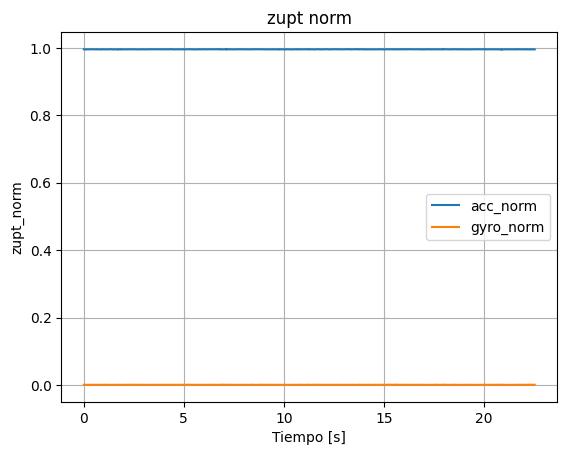

In [106]:
plt.figure()
plt.plot(t, df_u["acc_norm"], label="acc_norm")
plt.plot(t, df_u["gyro_norm"], label="gyro_norm")
# plt.plot(t, alx, label='ax original', alpha=0.4)
# plt.plot(t, df_u["zupt_score"], label="zupt_score", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("zupt_norm")
plt.legend()
plt.grid(True)
plt.title("zupt norm")
plt.show()

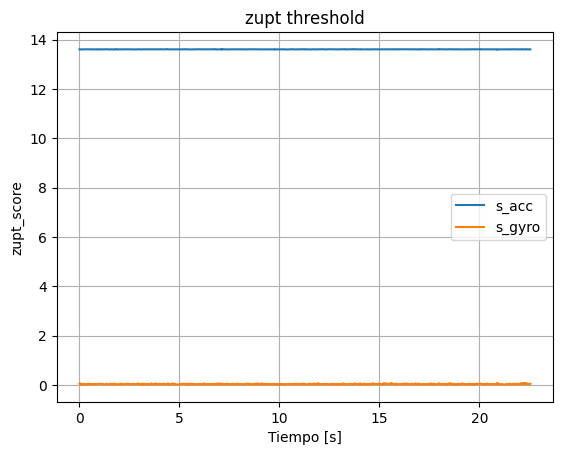

In [107]:
plt.figure()
plt.plot(t, df_u["s_acc"], label="s_acc")
plt.plot(t, df_u["s_gyro"], label="s_gyro")
# plt.plot(t, alx, label='ax original', alpha=0.4)
# plt.plot(t, df_u["zupt_score"], label="zupt_score", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("zupt_score")
plt.legend()
plt.grid(True)
plt.title("zupt threshold")
plt.show()

In [108]:
"""# 1. ZUPT DURO
if ||a|| < ACC_TH and ||ω|| < GYRO_TH:
    v = 0

# 2. ZUPT como realimentación
vk+1​ = vk ​− Kzupt​ vk​

# 3. Detector zupT continuo (sin umbral duro)
# 3.1 Metrica de reposo (score)
acc_norm  = np.linalg.norm(a_body)
gyro_norm = np.linalg.norm(g)

s_acc  = acc_norm  / ACC_TH
s_gyro = gyro_norm / GYRO_TH

zupt_score = max(s_acc, s_gyro)

# 3.2 Activacion suave (funcion logistica)
def smooth_step(x, x0=1.0, k=10.0):
    return 1.0 / (1.0 + np.exp(k*(x - x0)))

w_zupt = smooth_step(zupt_score) 
# w_zupt = 1 -> ZUPT fuerte
# w_zupt = 0 -> sin ZUPT

# 4 ZUPT suave con ganancia
K_zupt = 0.5 # ganancia ZUPT (tuneable)

v -= K_zupt * w_zupt * v

# 5 HNC suave (no holonómica bien hecha)
# 5.1 Pasar velocidad a body
v_body = R_nb.T @ v"""

'# 1. ZUPT DURO\nif ||a|| < ACC_TH and ||ω|| < GYRO_TH:\n    v = 0\n\n# 2. ZUPT como realimentación\nvk+1\u200b = vk \u200b− Kzupt\u200b vk\u200b\n\n# 3. Detector zupT continuo (sin umbral duro)\n# 3.1 Metrica de reposo (score)\nacc_norm  = np.linalg.norm(a_body)\ngyro_norm = np.linalg.norm(g)\n\ns_acc  = acc_norm  / ACC_TH\ns_gyro = gyro_norm / GYRO_TH\n\nzupt_score = max(s_acc, s_gyro)\n\n# 3.2 Activacion suave (funcion logistica)\ndef smooth_step(x, x0=1.0, k=10.0):\n    return 1.0 / (1.0 + np.exp(k*(x - x0)))\n\nw_zupt = smooth_step(zupt_score) \n# w_zupt = 1 -> ZUPT fuerte\n# w_zupt = 0 -> sin ZUPT\n\n# 4 ZUPT suave con ganancia\nK_zupt = 0.5 # ganancia ZUPT (tuneable)\n\nv -= K_zupt * w_zupt * v\n\n# 5 HNC suave (no holonómica bien hecha)\n# 5.1 Pasar velocidad a body\nv_body = R_nb.T @ v'

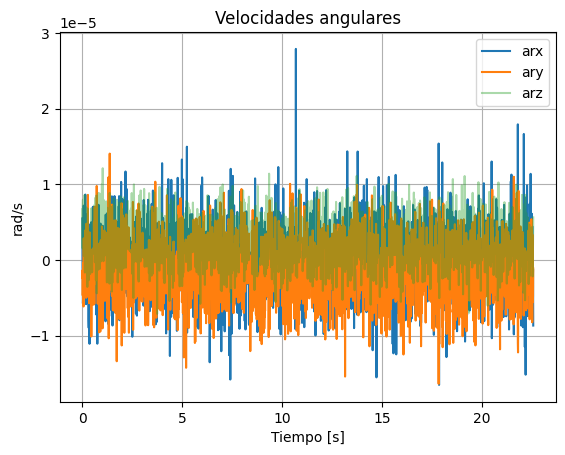

array([ 2.46544892e-07,  2.42505264e-07,  1.04193869e-07, ...,
       -3.54867144e-06, -2.49554396e-06, -7.74879810e-07], shape=(22868,))

In [109]:
plt.figure()
plt.plot(t, df_u["arx"], label="arx")
plt.plot(t, df_u["ary"], label="ary")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["arz"], label="arz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares")
plt.show()

arx_f	

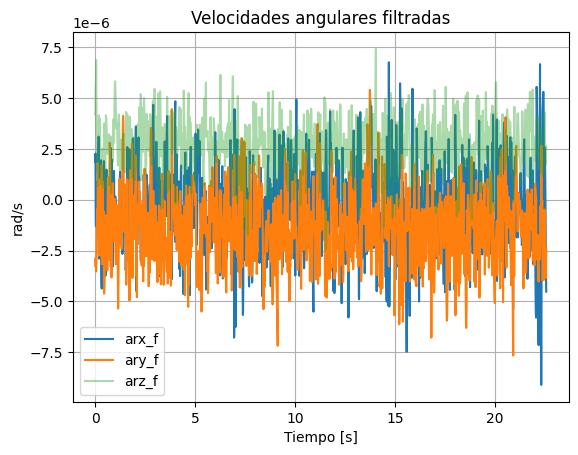

In [110]:
plt.figure()
plt.plot(t, df_u["arx_f"], label="arx_f")
plt.plot(t, df_u["ary_f"], label="ary_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["arz_f"], label="arz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares filtradas")
plt.show()

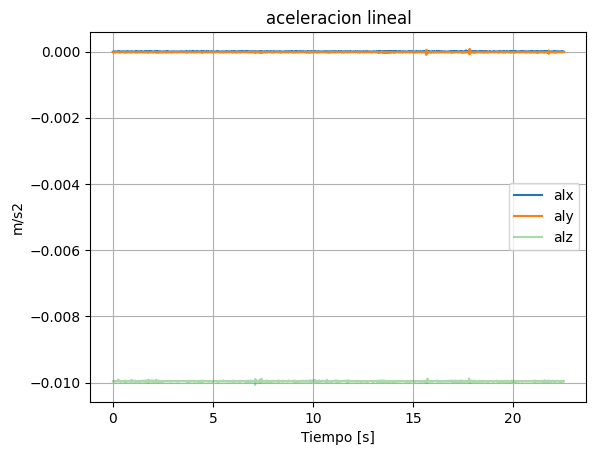

In [111]:
plt.figure()
plt.plot(t, df_u["alx"], label="alx")
plt.plot(t, df_u["aly"], label="aly")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["alz"], label="alz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion lineal")
plt.show()

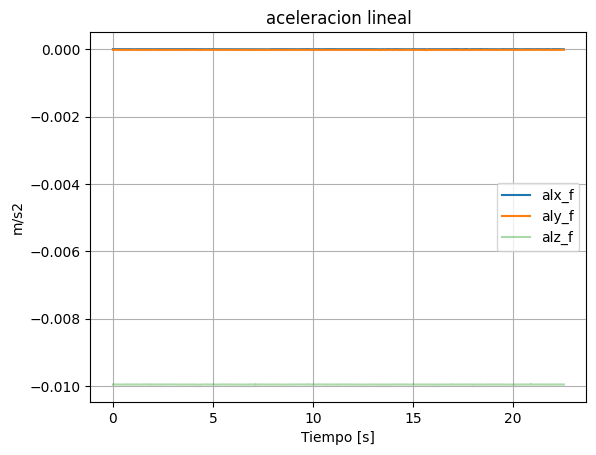

In [112]:
plt.figure()
plt.plot(t, df_u["alx_f"], label="alx_f")
plt.plot(t, df_u["aly_f"], label="aly_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["alz_f"], label="alz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion lineal")
plt.show()

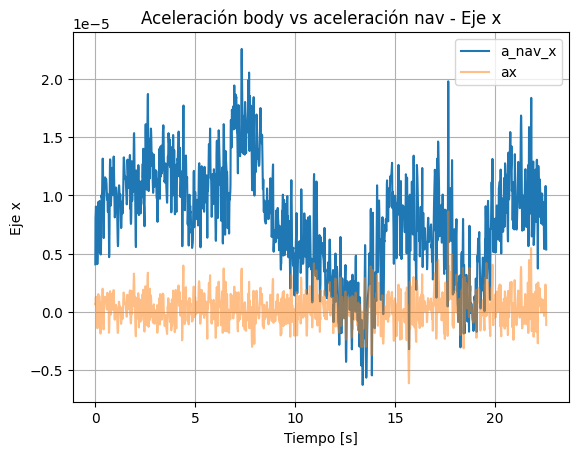

In [113]:
axi = "x"

plt.figure()

plt.plot(t, df_u[f"a_nav_{axi}"], label=f"a_nav_{axi}")
plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}", alpha=0.5)
# plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
# plt.plot(t, df_u[f"p{axi}"], label=f"p{axi}")
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Eje {axi}")
plt.legend()
plt.grid(True)
plt.title(f"Aceleración body vs aceleración nav - Eje {axi}")
plt.show()

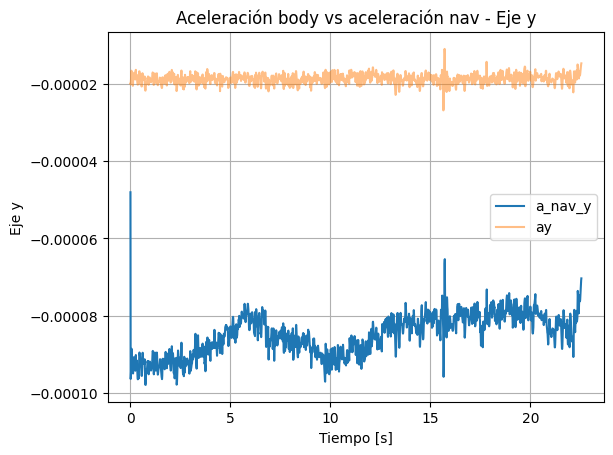

In [114]:
axi = "y"

plt.figure()

plt.plot(t, df_u[f"a_nav_{axi}"], label=f"a_nav_{axi}")
plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}", alpha=0.5)
# plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
# plt.plot(t, df_u[f"p{axi}"], label=f"p{axi}")
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Eje {axi}")
plt.legend()
plt.grid(True)
plt.title(f"Aceleración body vs aceleración nav - Eje {axi}")
plt.show()

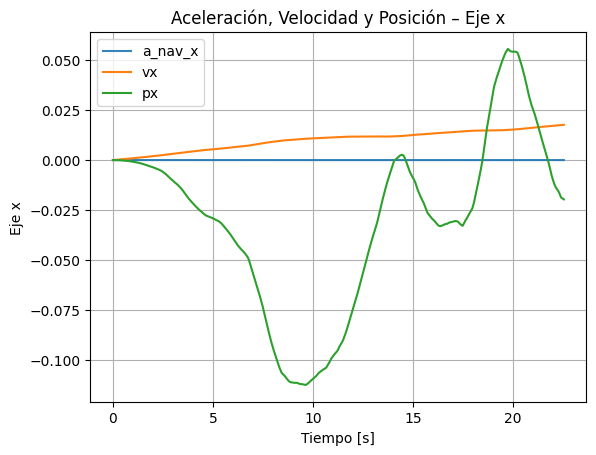

In [115]:
def plot_unEje_ac_v_p(axi):
    plt.figure()

    plt.plot(t, df_u[f"a_nav_{axi}"], label=f"a_nav_{axi}", alpha=0.9)
    # plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}")
    plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
    plt.plot(t, df_u[f"p{axi}"], label=f"p{axi}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Eje {axi}")
    plt.legend()
    plt.grid(True)
    plt.title(f"Aceleración, Velocidad y Posición – Eje {axi}")
    plt.show()

plot_unEje_ac_v_p("x")

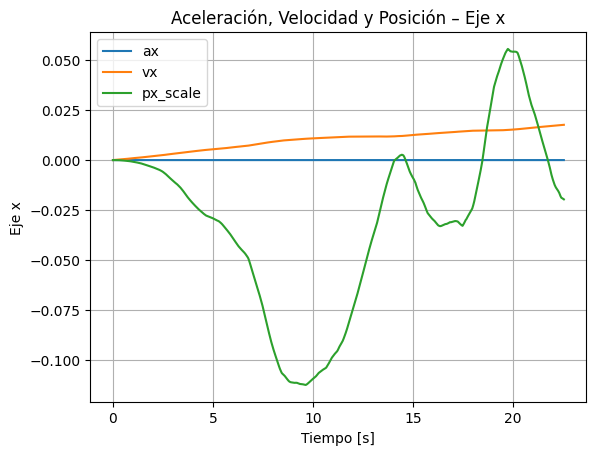

In [116]:
def plot_unEje_ac_v_p(axi):
    plt.figure()
    plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}")
    plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
    plt.plot(t, df_u[f"p{axi}_scale"], label=f"p{axi}_scale")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Eje {axi}")
    plt.legend()
    plt.grid(True)
    plt.title(f"Aceleración, Velocidad y Posición – Eje {axi}")
    plt.show()

plot_unEje_ac_v_p("x")

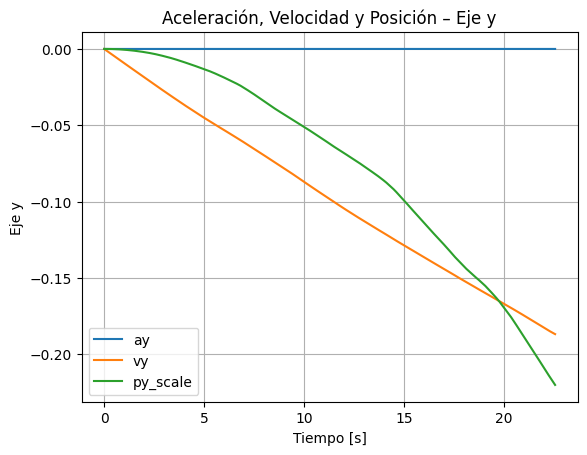

In [117]:
# import matplotlib as plt
# # def plot_unEje_ac_v_p():
# plt.figure()
# plt.plot(t, df_u["aly_f"], label="ay")
# plt.plot(t, df_u["vy"], label="vy")
# plt.plot(t, df_u["py"], label="py")
# plt.xlabel("Tiempo [s]")
# plt.ylabel("Eje Y")
# plt.legend()
# plt.grid(True)
# plt.title("Aceleración, Velocidad y Posición – Eje Y")
# plt.show()
# # plot_unEje_ac_v_p()

plot_unEje_ac_v_p("y")

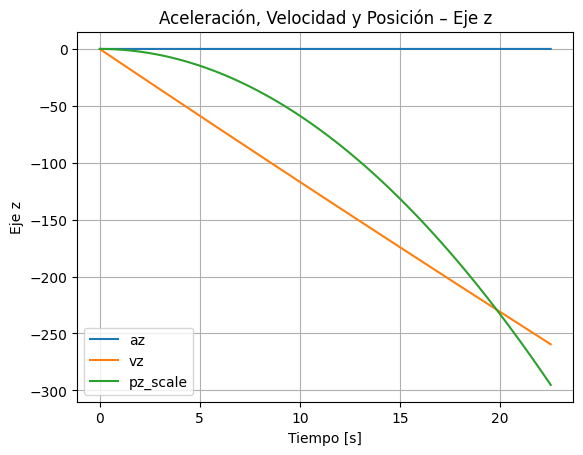

In [118]:
# import matplotlib as plt
# # def plot_unEje_ac_v_p():
# plt.figure()
# plt.plot(t, df_u["aly_f"], label="ay")
# plt.plot(t, df_u["vy"], label="vy")
# plt.plot(t, df_u["py"], label="py")
# plt.xlabel("Tiempo [s]")
# plt.ylabel("Eje Y")
# plt.legend()
# plt.grid(True)
# plt.title("Aceleración, Velocidad y Posición – Eje Y")
# plt.show()
# # plot_unEje_ac_v_p()

plot_unEje_ac_v_p("z")

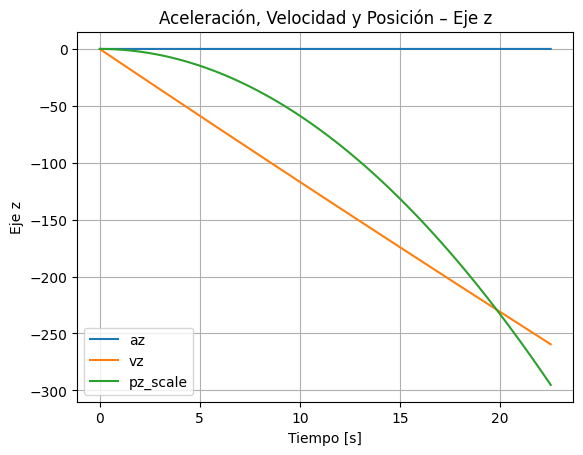

In [119]:
# plt.figure()
# plt.plot(t, df_u["alz_f"], label="az")
# plt.plot(t, df_u["vz"], label="vz")
# plt.plot(t, df_u["pz"], label="pz")
# plt.xlabel("Tiempo [s]")
# plt.ylabel("Eje Z")
# plt.legend()
# plt.grid(True)
# plt.title("Aceleración, Velocidad y Posición – Eje Z")
# plt.show()

plot_unEje_ac_v_p("z")

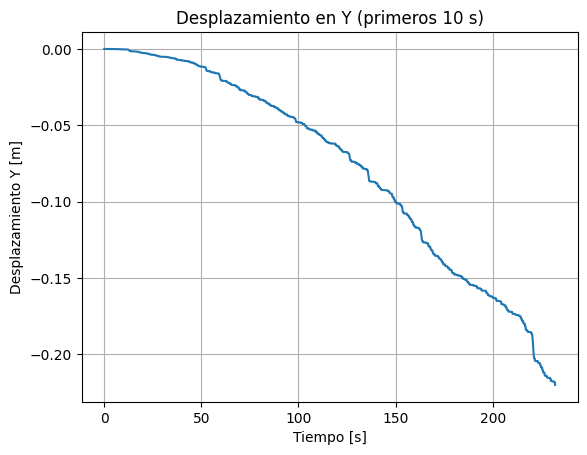

In [120]:
df_u["time_s"] = (df_u["time"] - df_u["time"].iloc[0]) * 1e-9
df_10s = df_u[df_u["time_s"] <= 300]
plt.figure()
plt.plot(df_10s["time_s"], df_10s["py_scale"])
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento Y [m]")
plt.title("Desplazamiento en Y (primeros 10 s)")
plt.grid(True)
plt.show()

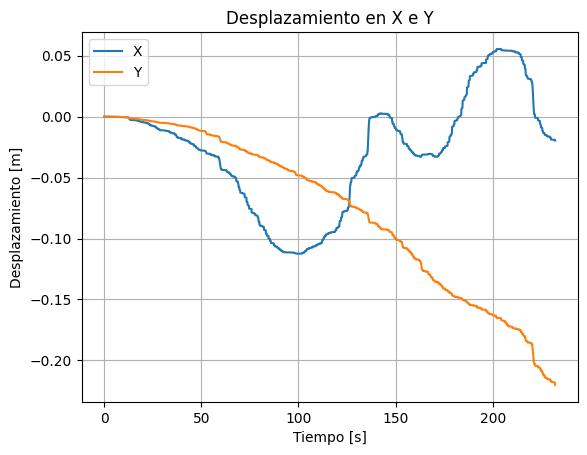

In [121]:
plt.figure()
plt.plot(df_10s["time_s"], df_10s["px_scale"], label="X")
plt.plot(df_10s["time_s"], df_10s["py_scale"], label="Y")

plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento [m]")
plt.title("Desplazamiento en X e Y")
plt.legend()
plt.grid(True)
plt.show()

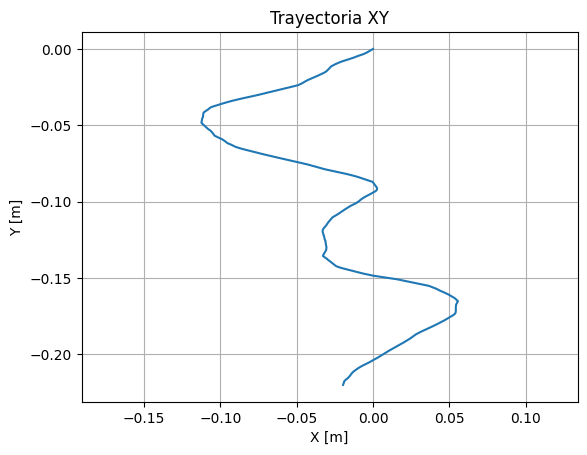

In [122]:
plt.figure()
plt.plot(df_10s["px_scale"], df_10s["py_scale"])
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Trayectoria XY")
plt.axis("equal")  # Importante para INS
plt.grid(True)
plt.show()

In [123]:
a = df_u.loc[5, ["alx", "aly", "alz"]].values
norm = np.linalg.norm(a)
a_norm = a / np.linalg.norm(a)
print(a)
print(norm)
print(a_norm)
print(a[0], abs(a[0]))

[-2.44093030e-06 -1.79817089e-05 -9.94661450e-03]
0.009946631057217365
[-2.45402719e-04 -1.80781903e-03 -9.99998336e-01]
-2.440930302327615e-06 2.440930302327615e-06


In [124]:
def plot_unEje(df, axi, params, save_path):

    plt.figure()
    plt.plot(t, df[f"al{axi}_f"], label=f"a{axi}")
    plt.plot(t, df[f"v{axi}"], label=f"v{axi}")
    plt.plot(t, df[f"p{axi}"], label=f"p{axi}")

    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Eje {axi}")
    plt.legend()
    plt.grid(True)

    title = (
        f"ACC_TH={params['ACC_TH']} | "
        f"GYRO_TH={params['GYRO_TH']} | "
        f"ZUPT_GAIN={params['ZUPT_GAIN']} | "
        f"SIG={params['SIG_GAIN']}"
    )

    plt.title(title)
    plt.savefig(save_path)
    plt.close()

In [125]:
def plot_xyz(df, params, save_path):

    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    ejes = ["x", "y", "z"]

    for i, axi in enumerate(ejes):

        axes[i].plot(t, df[f"al{axi}_f"], label=f"a{axi}")
        axes[i].plot(t, df[f"v{axi}"], label=f"v{axi}")
        axes[i].plot(t, df[f"p{axi}"], label=f"p{axi}")

        axes[i].set_ylabel(f"Eje {axi}")
        axes[i].grid(True)
        axes[i].legend()

    axes[2].set_xlabel("Tiempo [s]")

    title = (
        f"ACC_TH={params['ACC_TH']} | "
        f"GYRO_TH={params['GYRO_TH']} | "
        f"ZUPT_GAIN={params['ZUPT_GAIN']} | "
        f"SIG={params['SIG_GAIN']}"
    )

    fig.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(save_path)
    plt.close()

In [126]:
import os
import itertools

# ruta_resultados = "resultados2"

os.makedirs(ruta_resultados, exist_ok=True)

ACC_TH_vals = [0.144, 0.269] # [0.102, 0.144, 0.269, 0.353, 0.437]
GYRO_TH_vals = [0.011, 0.017] # [0.006, 0.011, 0.017, 0.022, 0.028]
ZUPT_GAIN_vals = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
SIGMOID_GAIN_vals = [1, 5, 10, 15, 20]

def ins_tuning():
    for ACC_TH, GYRO_TH, ZUPT_GAIN, SIG_GAIN in itertools.product(
            ACC_TH_vals,
            GYRO_TH_vals,
            ZUPT_GAIN_vals,
            SIGMOID_GAIN_vals):

        df_test = df_u.copy()

        ins(
            df_test,
            ACC_TH=ACC_TH,
            GYRO_TH=GYRO_TH,
            ZUPT_GAIN=ZUPT_GAIN,
            ZUPT_SIGMOID_GAIN=SIG_GAIN
        )

        params = {
            "ACC_TH": ACC_TH,
            "GYRO_TH": GYRO_TH,
            "ZUPT_GAIN": ZUPT_GAIN,
            "SIG_GAIN": SIG_GAIN
        }

        filename = f"{ruta_resultados}/A{ACC_TH}_G{GYRO_TH}_Z{ZUPT_GAIN}_S{SIG_GAIN}.png"
        
        plot_xyz(df_test, params, filename)

In [127]:
# ins_tuning()

In [128]:
# # ZUPT parcial

# EPS_ACCEL = 0.1      # m/s^2
# VAR_ACCEL = 0.02     # (m/s^2)^2
# MIN_SAMPLES = int(1.0 * fs)

# zupt = np.zeros(len(accel_filt), dtype=bool)
# counter = 0

# for k in range(N, len(accel_filt)):
#     acc_win = accel_filt[k-N:k]
    
#     acc_var = np.mean(np.var(acc_win, axis=0))
#     acc_dev = abs(acc_norm[k] - g)

#     stationary = (
#         acc_dev < EPS_ACCEL and
#         acc_var < VAR_ACCEL
#     )

#     if stationary:
#         counter += 1
#         if counter >= MIN_SAMPLES:
#             zupt[k] = True
#     else:
#         counter = 0

In [129]:
# # magnitud total del ZUPT

# acc_mag = np.sqrt(ax**2 + ay**2 + az**2)
# acc_mag_f = np.sqrt(ax_f**2 + ay_f**2 + az_f**2)

# plt.figure(figsize=(12,6))
# plt.plot(t, acc_mag, label='|a| original', alpha=0.4)
# plt.plot(t, acc_mag_f, label='|a| filtrado', linewidth=2)
# plt.axhline(9.81, color='k', linestyle='--', label='g')
# plt.legend()
# plt.grid()
# plt.title("Magnitud de aceleración")
# plt.show()

In [130]:
# Diseño de umbrales para ZUPT (criterio práctico)

# ZUPT no se diseña “a ojo”, se basa en:

# Aceleración cerca de g

# Baja varianza

# Giroscopio bajo (si lo tienes)

# Umbrales típicos (100 Hz)
# Variable	Umbral típico
# |a| − g	< 0.05 – 0.15 m/s²
# σ(a) ventana	< 0.02 – 0.05 m/s²
# |ω|	< 0.5 – 2 deg/s
# Ventana	0.2 – 0.5 s

In [131]:
# Eso es ingeniería bien hecha:

# FFT → identificar banda útil

# Allan → ruido y bias

# Datos reales → ajustar fc y umbrales

In [132]:
# from scipy.signal import sosfilt

# # gyro_filt = sosfilt(sos, gyro_raw)
# accel_filt = sosfilt(sos, accel_raw)

In [133]:
# from scipy.signal import sosfiltfilt

# gyro_filt = sosfiltfilt(sos, gyro_raw)